In [ ]:
#1
!pip install -q tensorflow scikit-learn pandas numpy matplotlib seaborn holidays requests shap joblib pulp

In [ ]:
from google.colab import drive
import os
import pandas as pd

drive.mount('/content/drive')

sem_file = "/content/drive/MyDrive/STLF/Demand_15min.csv"

print("CSV headers:",
      pd.read_csv(sem_file, nrows=0, encoding="latin1").columns.tolist())


Mounted at /content/drive
CSV headers: ['PK\x03\x04\x14']


In [ ]:
!file "/content/drive/MyDrive/STLF/Demand_15min.csv"


/content/drive/MyDrive/STLF/Demand_15min.csv: Microsoft Excel 2007+


In [ ]:
excel_path = "/content/drive/MyDrive/STLF/Demand_15min.csv"

df = pd.read_excel(excel_path)

print(df.columns)
df.head()


Index(['Time', 'BSEB Sch', 'JSEB Sch', 'DVC Sch', 'GRIDCO Sch', 'WBSEB Sch',
       'SIKKIM Sch', 'BSEB Act', 'JSEB Act', 'DVC Act', 'GRIDCO Act',
       'WBSEB Act', 'SIKKIM Act'],
      dtype='object')


,Time,BSEB Sch,JSEB Sch,DVC Sch,GRIDCO Sch,WBSEB Sch,SIKKIM Sch,BSEB Act,JSEB Act,DVC Act,GRIDCO Act,WBSEB Act,SIKKIM Act
0,01-01-2022 00:00,2527.195981,915.255289,-974.365222,2783.186894,-318.462894,62.148492,2530.768912,764.550560,-1050.269040,2524.013004,-230.133272,52.213564
1,01-01-2022 00:15,2504.730979,914.665289,-975.325722,2641.562619,-219.200344,60.148492,2488.483452,744.598116,-1087.608048,2569.670316,-293.042836,53.049204
2,01-01-2022 00:30,2607.223383,777.982197,-979.167722,2858.826499,-145.767971,59.402542,2456.512616,736.999356,-1056.169188,2686.350860,-370.311540,52.332208
3,01-01-2022 00:45,2544.173400,777.322197,-979.167722,2858.708309,-200.767971,57.402542,2433.970280,723.857420,-1006.062056,2688.441840,-438.634472,50.653416
4,01-01-2022 01:00,2418.831724,737.563764,-889.917222,2857.134540,-348.585828,57.628250,2405.003616,712.564400,-1079.938180,2534.639244,-487.026416,49.620960


In [ ]:
fixed_csv = "/content/drive/MyDrive/STLF/Demand_15min_fixed.csv"
df.to_csv(fixed_csv, index=False)

print("Saved clean CSV at:", fixed_csv)



Saved clean CSV at: /content/drive/MyDrive/STLF/Demand_15min_fixed.csv


In [ ]:
sem_file = "/content/drive/MyDrive/STLF/Demand_15min_fixed.csv"



In [ ]:
# Define project base folder
base_path = "/content/drive/MyDrive/STLF_project"

# Create required folders if not exist
import os
for d in ["data", "models", "plots", "logs"]:
    os.makedirs(os.path.join(base_path, d), exist_ok=True)

print("Base path ready:", base_path)


Base path ready: /content/drive/MyDrive/STLF_project


In [ ]:
#3
import pandas as pd
import numpy as np
import os

def load_and_preprocess_data(sem_file, base_path):
    # Load raw SEM.csv with date parsing
    sem_data = pd.read_csv(sem_file, dtype=str)
    sem_data = sem_data.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)

    if 'Time' not in sem_data.columns:
        raise ValueError("No 'Time' column found in SEM.csv")

    sem_data['Time'] = pd.to_datetime(sem_data['Time'], dayfirst=True, errors='coerce')

    #rop rows with invalid or missing datetime
    bad_rows = sem_data[sem_data['Time'].isnull()]
    if not bad_rows.empty:
        print(f"Dropping {len(bad_rows)} rows with invalid datetime.")
        sem_data = sem_data.dropna(subset=['Time'])

    sem_data = sem_data.drop_duplicates(subset=['Time']).sort_values('Time').reset_index(drop=True)

    sem_data = sem_data.rename(columns={'Time': 'datetime'}).set_index('datetime')

    #select demand columns (usually contain 'Act' substring)
    demand_cols = [col for col in sem_data.columns if 'Act' in col]

    for col in demand_cols:
        sem_data[col] = pd.to_numeric(sem_data[col], errors='coerce')
        # Clip outliers between 1st and 99th percentile
        p1, p99 = sem_data[col].quantile([0.01, 0.99])
        sem_data[col] = np.clip(sem_data[col], p1, p99)
        # Interpolate and backfill missing values
        sem_data[col] = sem_data[col].interpolate(method='linear').bfill()

    # Resample at 5-min intervals with linear interpolation
    demand_5min = sem_data[demand_cols]
    idx_5min = pd.date_range(demand_5min.index.min(), demand_5min.index.max(), freq='5min')
    demand_5min = demand_5min.reindex(idx_5min).interpolate('time').bfill().ffill()

    output_path = os.path.join(base_path, 'data', 'demand_5min.csv')
    demand_5min.to_csv(output_path, index_label='datetime')
    print(f"Saved resampled demand_5min.csv at {output_path} with shape {demand_5min.shape}")

    return demand_5min, demand_cols

demand_5min, demand_columns = load_and_preprocess_data(sem_file, base_path)

Dropping 2880 rows with invalid datetime.
Saved resampled demand_5min.csv at /content/drive/MyDrive/STLF_project/data/demand_5min.csv with shape (105118, 6)


In [ ]:
# ===== DIMENSION-2 : Hierarchical Power Flow Features =====

grid_map = {
    "DVC": "DVC Act",
    "BSEB": "BSEB Act",
    "WBSEB": "WBSEB Act",
    "SIKKIM": "SIKKIM Act"
}

# Extract power series
DVC = demand_5min[grid_map["DVC"]]
BSEB = demand_5min[grid_map["BSEB"]]
WBSEB = demand_5min[grid_map["WBSEB"]]
SIKKIM = demand_5min[grid_map["SIKKIM"]]

# Power drawn from DVC
demand_5min["Total_Draw"] = BSEB + WBSEB + SIKKIM

# Net grid balance
demand_5min["Grid_Balance"] = DVC - demand_5min["Total_Draw"]

# Load stress indicator
demand_5min["DVC_Utilization"] = demand_5min["Total_Draw"] / (DVC + 1e-6)

# Congestion flag
demand_5min["Grid_Stress"] = (demand_5min["DVC_Utilization"] > 0.9).astype(int)

print("Grid physics features added")
demand_5min[["Total_Draw","Grid_Balance","DVC_Utilization","Grid_Stress"]].head()


Grid physics features added


,Total_Draw,Grid_Balance,DVC_Utilization,Grid_Stress
2022-01-01 00:00:00,2352.849204,-3403.118244,-2.240235,0
2022-01-01 00:05:00,2318.062743,-3380.778119,-2.181264,0
2022-01-01 00:10:00,2283.276281,-3358.437993,-2.123658,0
2022-01-01 00:15:00,2248.489820,-3336.097868,-2.067371,0
2022-01-01 00:20:00,2211.837641,-3288.966069,-2.053458,0


In [ ]:
# ===== DIMENSION-3 : Renewable + Market + Risk Intelligence =====

import numpy as np

np.random.seed(42)

idx = demand_5min.index

# --- Synthetic renewable generation (can replace later with real data) ---
demand_5min["Solar_MW"] = (
    0.6 * np.maximum(0, np.sin((idx.hour - 6) / 12 * np.pi)) * 500
    + np.random.normal(0, 40, len(idx))
)

demand_5min["Wind_MW"] = (
    300 + 80 * np.sin(idx.hour / 24 * 2 * np.pi)
    + np.random.normal(0, 60, len(idx))
)

demand_5min["Renewable_Total"] = (
    demand_5min["Solar_MW"] + demand_5min["Wind_MW"]
)

# --- Net demand on DVC after renewables ---
demand_5min["Net_Demand"] = demand_5min["Total_Draw"] - demand_5min["Renewable_Total"]

# --- Market price signal (demand-driven) ---
demand_5min["Market_Price"] = (
    3 + 0.002 * demand_5min["Net_Demand"]
    + np.random.normal(0, 0.2, len(idx))
)

# --- Ramp rate (demand change speed) ---
demand_5min["Ramp_Rate"] = demand_5min["Net_Demand"].diff().fillna(0)

# --- Volatility (rolling std of ramp rate) ---
demand_5min["Volatility"] = demand_5min["Ramp_Rate"].rolling(12).std().fillna(0)

# --- Renewable penetration ratio ---
demand_5min["RE_Penetration"] = (
    demand_5min["Renewable_Total"] / (demand_5min["Total_Draw"] + 1e-6)
)

# --- Forecast risk indicator ---
demand_5min["Forecast_Risk"] = (
    (demand_5min["Grid_Stress"] == 1).astype(int) +
    (demand_5min["RE_Penetration"] > 0.4).astype(int) +
    (demand_5min["Volatility"] > demand_5min["Volatility"].quantile(0.85)).astype(int)
)

print("Dimension-3 (Market + Renewable + Risk) features added")
demand_5min[
    ["Solar_MW", "Wind_MW", "Renewable_Total",
     "Net_Demand", "Market_Price",
     "Ramp_Rate", "Volatility",
     "RE_Penetration", "Forecast_Risk"]
].head()


Dimension-3 (Market + Renewable + Risk) features added


,Solar_MW,Wind_MW,Renewable_Total,Net_Demand,Market_Price,Ramp_Rate,Volatility,RE_Penetration,Forecast_Risk
2022-01-01 00:00:00,19.868566,339.989667,359.858233,1992.990971,7.155841,0.000000,0.0,0.152946,0
2022-01-01 00:05:00,-5.530572,382.287432,376.756860,1941.305882,7.035839,-51.685089,0.0,0.162531,0
2022-01-01 00:10:00,25.907542,323.263052,349.170593,1934.105688,6.866524,-7.200194,0.0,0.152925,0
2022-01-01 00:15:00,60.921194,413.182045,474.103239,1774.386581,6.760408,-159.719107,0.0,0.210854,0
2022-01-01 00:20:00,-9.366135,250.513062,241.146927,1970.690715,7.028560,196.304134,0.0,0.109026,0


In [ ]:
import numpy as np

# Node order:
# 0 = DVC, 1 = BSEB, 2 = WBSEB, 3 = SIKKIM

A = np.array([
    [1, 1, 1, 1],   # DVC connected to all
    [1, 1, 0, 0],   # BSEB ↔ DVC
    [1, 0, 1, 0],   # WBSEB ↔ DVC
    [1, 0, 0, 1],   # SIKKIM ↔ DVC
], dtype=np.float32)

# GCN normalization:  A_hat = D^(-1/2) A D^(-1/2)
D = np.diag(np.sum(A, axis=1))
D_inv_sqrt = np.linalg.inv(np.sqrt(D))
A_norm = D_inv_sqrt @ A @ D_inv_sqrt

A_norm


array([[0.25      , 0.35355338, 0.35355338, 0.35355338],
       [0.35355338, 0.49999997, 0.        , 0.        ],
       [0.35355338, 0.        , 0.49999997, 0.        ],
       [0.35355338, 0.        , 0.        , 0.49999997]], dtype=float32)

In [ ]:
class GraphConv(tf.keras.layers.Layer):
    def __init__(self, units, A_norm, **kwargs):
        super(GraphConv, self).__init__(**kwargs)
        self.units = units
        self.A_norm = tf.constant(A_norm, dtype=tf.float32)

    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer="glorot_uniform",
            trainable=True
        )

    def call(self, X):
        # X shape = (batch, time, nodes, features)
        AX = tf.einsum("ij,btjf->btif", self.A_norm, X)
        return tf.nn.relu(tf.einsum("btif,fg->btig", AX, self.W))

    # 🔥 THIS MAKES IT SERIALIZABLE
    def get_config(self):
        config = super().get_config()
        config.update({
            "units": self.units,
            "A_norm": self.A_norm.numpy().tolist()
        })
        return config


In [ ]:
grid_cols = ['DVC Act', 'BSEB Act', 'WBSEB Act', 'SIKKIM Act']

grid_data = demand_5min[grid_cols].values

# reshape into (samples, time_steps, nodes, features)
seq_len = 12   # 1 hour history
num_nodes = 4

X_graph = []
y_graph = []

for i in range(len(grid_data) - seq_len):
    X_graph.append(grid_data[i:i+seq_len])
    y_graph.append(grid_data[i+seq_len])

X_graph = np.array(X_graph).reshape(-1, seq_len, num_nodes, 1)
y_graph = np.array(y_graph)

print("Graph input shape:", X_graph.shape)


Graph input shape: (105106, 12, 4, 1)


In [ ]:
from tensorflow.keras.layers import Input, LSTM, Dense, MultiHeadAttention, Reshape
from tensorflow.keras.models import Model
import tensorflow as tf

# Inputs: (batch, time, nodes, features)
inputs = Input(shape=(seq_len, 4, 1))

# ----- GRAPH CONVOLUTION -----
gcn = GraphConv(16, A_norm)(inputs)      # (batch, time, nodes, 16)

# Flatten node dimension → feed to LSTM
gcn_flat = Reshape((seq_len, 4 * 16))(gcn)   # (batch, time, 64)

# ----- TEMPORAL MODELING -----
lstm = LSTM(64, return_sequences=True)(gcn_flat)

# ----- ATTENTION -----
attn = MultiHeadAttention(num_heads=4, key_dim=16)(lstm, lstm)

# ----- DENSE HEAD -----
dense = Dense(32, activation='relu')(attn)

# ----- PROBABILISTIC OUTPUT -----
# [μ_DVC, μ_BSEB, μ_WBSEB, μ_SIKKIM,
#  logσ²_DVC, logσ²_BSEB, logσ²_WBSEB, logσ²_SIKKIM]
output = Dense(8)(dense[:, -1, :])

model = Model(inputs, output)

# Gaussian negative log likelihood
def gaussian_nll(y_true, y_pred):
    mu = y_pred[:, :4]       # predicted means
    log_var = y_pred[:, 4:]  # predicted log variances
    var = tf.exp(log_var)

    nll = 0.5 * (log_var + tf.square(y_true - mu) / (var + 1e-6))
    return tf.reduce_mean(nll)


model.compile(
    optimizer="adam",
    loss=gaussian_nll
)


model.summary()



Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 12, 4, 1)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ graph_conv_8        │ (None, 12, 4, 16) │         16 │ input_layer_8[0]… │
│ (GraphConv)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_7 (Reshape) │ (None, 12, 64)    │          0 │ graph_conv_8[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_11 (LSTM)      │ (None, 12, 64)    │     33,024 │ reshape_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 12, 64)    │     16,640 │ lstm_11[0][0],    │
│ (MultiHeadAttentio… │                   │            │ lstm_11[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 12, 32)    │      2,080 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_7          │ (None, 32)        │          0 │ dense_19[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 8)         │        264 │ get_item_7[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 52,024 (203.22 KB)

 Trainable params: 52,024 (203.22 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# STEP 1 – Train the Grid-Aware GCN-LSTM model

# X_graph shape: (samples, seq_len, 4, 1)
# Predict next-step load of all 4 grids
Y_graph = X_graph[:, -1, :, 0]   # (samples, 4)

print("X_graph:", X_graph.shape)
print("Y_graph:", Y_graph.shape)

history = model.fit(
    X_graph, Y_graph,
    epochs=25,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


X_graph: (105106, 12, 4, 1)
Y_graph: (105106, 4)
Epoch 1/25
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 51000.7227 - val_loss: 7.1451
Epoch 2/25
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 7.4333 - val_loss: 6.9624
Epoch 3/25
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 7.1570 - val_loss: 6.9554
Epoch 4/25
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 7.1305 - val_loss: 6.8899
Epoch 5/25
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 38s 9ms/step - loss: 7.0780 - val_loss: 6.6416
Epoch 6/25
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6.7124 - val_loss: 6.5389
Epoch 7/25
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 6.3730 - val_loss: 6.5044
Epoch 8/25
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - loss: 6.2378 - val_loss: 6.5082
Epoch 9/25
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6.1682 - val_loss: 6.3544
Epoch 10/25
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6.1271 - val_loss: 6.3333
Epoch 11/25
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 40s 8ms/ste

In [ ]:
model.save("/content/drive/MyDrive/STLF_project/models/gcn_spatial_model.keras")
print("GCN Spatial Model saved successfully.")


GCN Spatial Model saved successfully.


In [ ]:
y_pred = model.predict(X_graph)

mu = y_pred[:, :4]
sigma = np.exp(0.5 * y_pred[:, 4:])

for i, name in enumerate(["DVC", "BSEB", "WBSEB", "SIKKIM"]):
    mae = np.mean(np.abs(Y_graph[:, i] - mu[:, i]))
    print(f"{name} MAE = {mae:.2f} MW,  σ ≈ {sigma[:,i].mean():.2f} MW")


3285/3285 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step
DVC MAE = 129.43 MW,  σ ≈ 152.68 MW
BSEB MAE = 218.51 MW,  σ ≈ 270.15 MW
WBSEB MAE = 169.32 MW,  σ ≈ 314.25 MW
SIKKIM MAE = 18.50 MW,  σ ≈ 19.87 MW


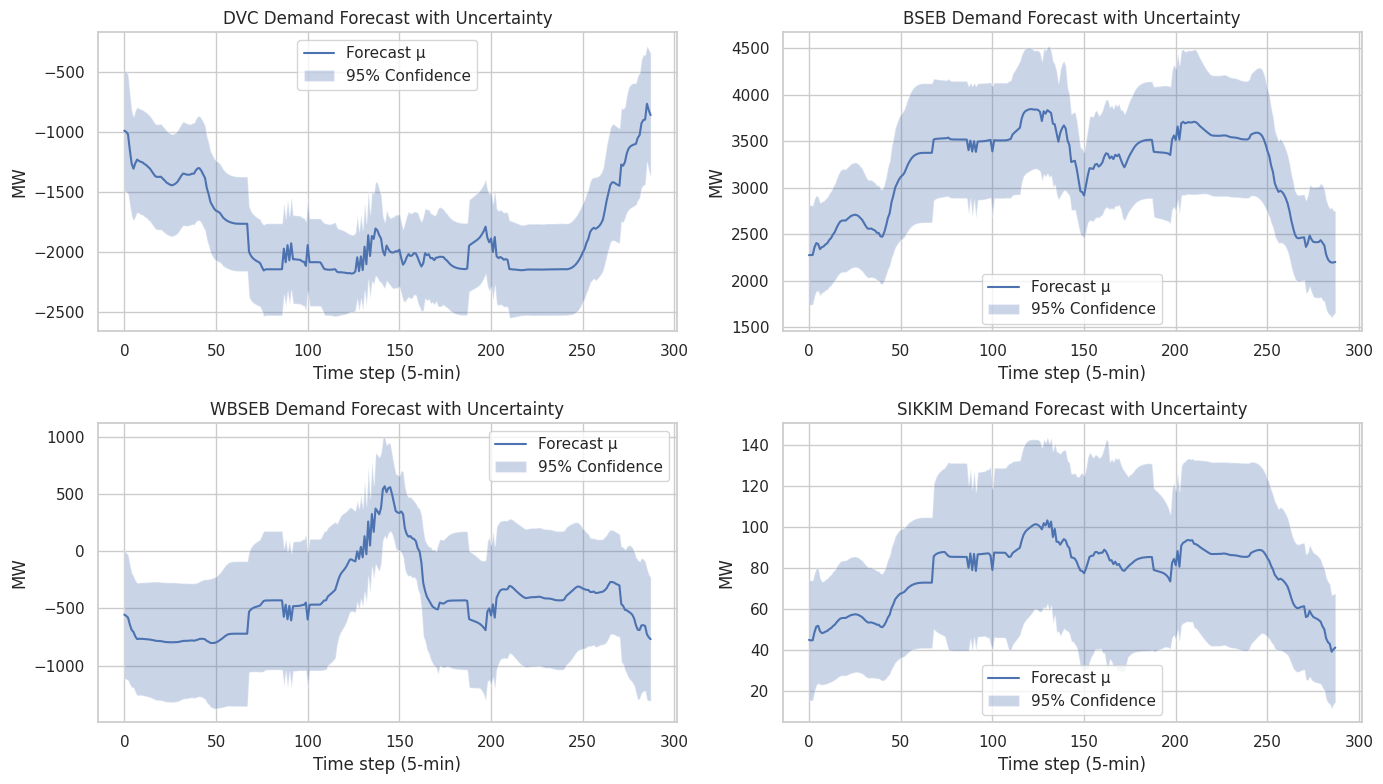

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plot only first day (288 points = 24h × 12)
T = 288
time = np.arange(T)

grid_names = ["DVC", "BSEB", "WBSEB", "SIKKIM"]

plt.figure(figsize=(14,8))

for i, name in enumerate(grid_names):
    plt.subplot(2,2,i+1)

    mean = mu[:T, i]
    std = sigma[:T, i]

    plt.plot(time, mean, label="Forecast μ")
    plt.fill_between(time, mean - 1.96*std, mean + 1.96*std,
                     alpha=0.3, label="95% Confidence")

    plt.title(name + " Demand Forecast with Uncertainty")
    plt.xlabel("Time step (5-min)")
    plt.ylabel("MW")
    plt.legend()

plt.tight_layout()
plt.show()


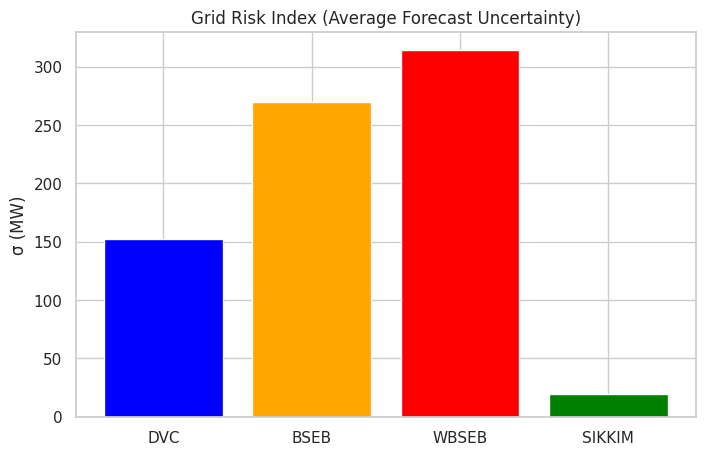

In [ ]:
risk_index = sigma.mean(axis=0)

plt.figure(figsize=(8,5))
plt.bar(grid_names, risk_index, color=["blue","orange","red","green"])
plt.title("Grid Risk Index (Average Forecast Uncertainty)")
plt.ylabel("σ (MW)")
plt.grid(True)
plt.show()


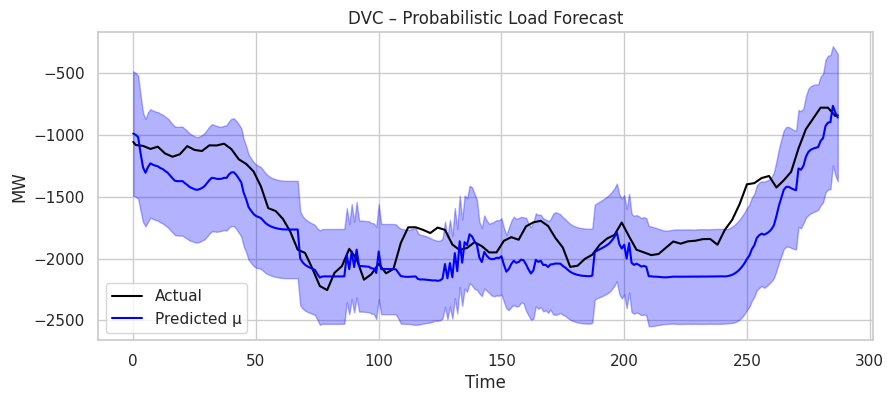

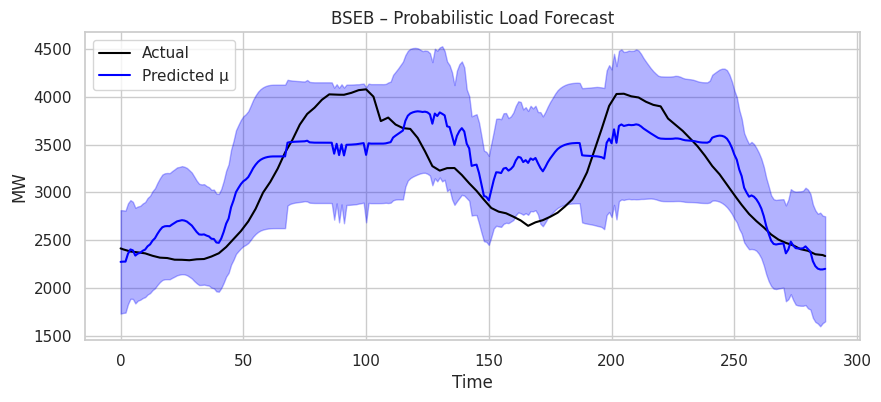

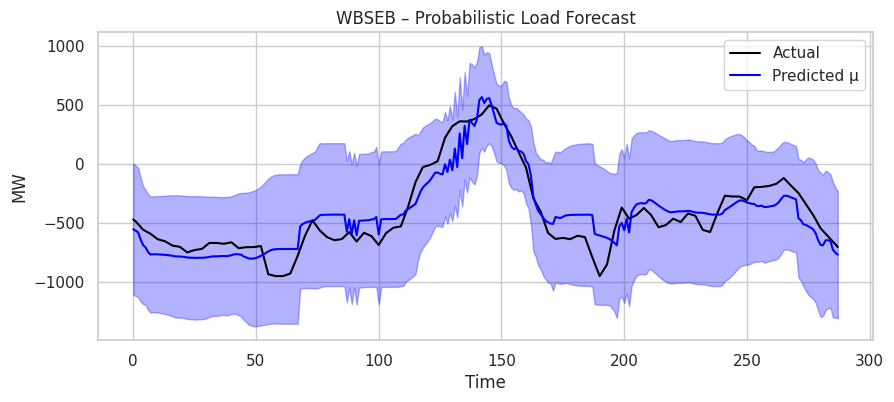

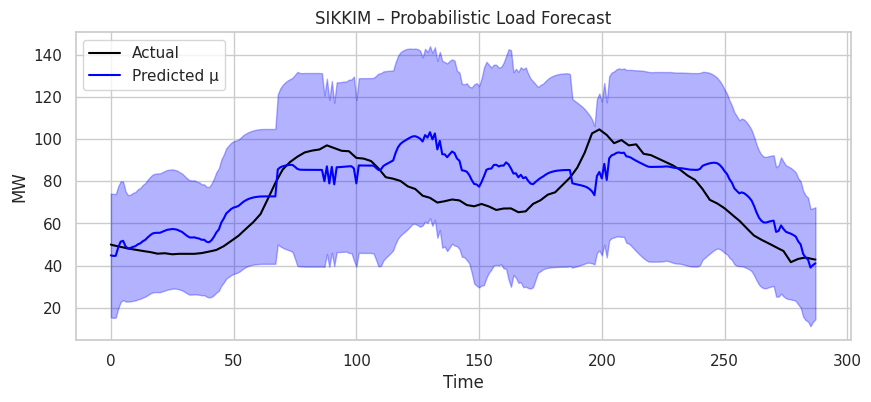

In [ ]:
actual = X_graph[:T, -1, :, 0]

for i, name in enumerate(grid_names):
    plt.figure(figsize=(10,4))
    plt.plot(actual[:,i], label="Actual", color="black")
    plt.plot(mu[:T,i], label="Predicted μ", color="blue")
    plt.fill_between(time,
                     mu[:T,i]-1.96*sigma[:T,i],
                     mu[:T,i]+1.96*sigma[:T,i],
                     color="blue", alpha=0.3)

    plt.title(name + " – Probabilistic Load Forecast")
    plt.xlabel("Time")
    plt.ylabel("MW")
    plt.legend()
    plt.show()


In [ ]:
coverage = []

for i in range(4):
    lower = mu[:,i] - 1.96*sigma[:,i]
    upper = mu[:,i] + 1.96*sigma[:,i]
    actual = X_graph[:, -1, i, 0]

    inside = np.mean((actual >= lower) & (actual <= upper))
    coverage.append(inside)

for g,c in zip(grid_names,coverage):
    print(f"{g} 95% CI Coverage = {c*100:.2f}%")


DVC 95% CI Coverage = 95.40%
BSEB 95% CI Coverage = 93.67%
WBSEB 95% CI Coverage = 99.22%
SIKKIM 95% CI Coverage = 94.26%


In [ ]:
import pandas as pd

original_15min_path = "/content/drive/MyDrive/STLF/Demand_15min.csv"

# Read Excel (even though extension is .csv)
original_15min = pd.read_excel(original_15min_path)

# Parse Time column
original_15min["Time"] = pd.to_datetime(original_15min["Time"], dayfirst=True)

# Set datetime index
original_15min = original_15min.set_index("Time").sort_index()

original_15min.head()


,BSEB Sch,JSEB Sch,DVC Sch,GRIDCO Sch,WBSEB Sch,SIKKIM Sch,BSEB Act,JSEB Act,DVC Act,GRIDCO Act,WBSEB Act,SIKKIM Act
Time,,,,,,,,,,,,
2022-01-01 00:00:00,2527.195981,915.255289,-974.365222,2783.186894,-318.462894,62.148492,2530.768912,764.550560,-1050.269040,2524.013004,-230.133272,52.213564
2022-01-01 00:15:00,2504.730979,914.665289,-975.325722,2641.562619,-219.200344,60.148492,2488.483452,744.598116,-1087.608048,2569.670316,-293.042836,53.049204
2022-01-01 00:30:00,2607.223383,777.982197,-979.167722,2858.826499,-145.767971,59.402542,2456.512616,736.999356,-1056.169188,2686.350860,-370.311540,52.332208
2022-01-01 00:45:00,2544.173400,777.322197,-979.167722,2858.708309,-200.767971,57.402542,2433.970280,723.857420,-1006.062056,2688.441840,-438.634472,50.653416
2022-01-01 01:00:00,2418.831724,737.563764,-889.917222,2857.134540,-348.585828,57.628250,2405.003616,712.564400,-1079.938180,2534.639244,-487.026416,49.620960


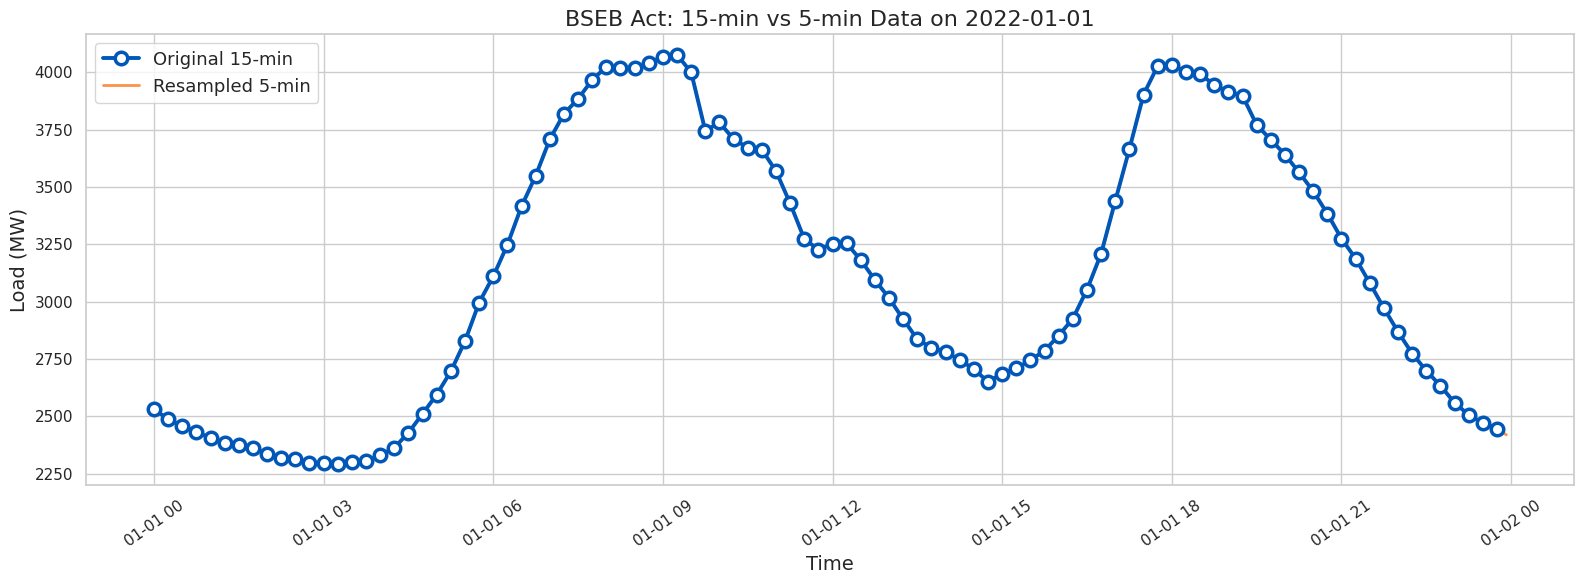

In [ ]:
#4
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

#load original 15-min data if not in memory
if 'original_15min' not in locals():
    sem_file = os.path.join(base_path, 'data', 'SEM.csv')
    original_15min = pd.read_csv(sem_file, parse_dates=['Time'], dayfirst=True)
    original_15min['Time'] = pd.to_datetime(original_15min['Time'], format='%d-%m-%Y %H:%M', errors='coerce')
    original_15min = original_15min.dropna(subset=['Time']).drop_duplicates(subset=['Time']).sort_values('Time').reset_index(drop=True)
    original_15min = original_15min.set_index('Time')

#load 5-min resampled data if not in memory
if 'demand_5min' not in locals():
    demand_5min = pd.read_csv(os.path.join(base_path, 'data', 'demand_5min.csv'), parse_dates=['datetime'], index_col='datetime')

#select demand column for plotting
if 'demand_columns' not in locals():
    demand_columns = [col for col in original_15min.columns if 'Act' in col]
demand_col = demand_columns[0] if demand_columns else demand_5min.columns[0]

plot_day = max(original_15min.index.min().date(), demand_5min.index.min().date()).isoformat()
day_start, day_end = pd.Timestamp(f"{plot_day} 00:00"), pd.Timestamp(f"{plot_day} 23:59")

if len(original_15min.loc[day_start:day_end]) and len(demand_5min.loc[day_start:day_end]):
    color_15min = "#0057b8"  #navy blue for 15-min
    color_5min = "#fc7c29"   #orange for 5-min

    plt.figure(figsize=(16, 6))
    sns.set_theme(style="whitegrid")

    #original 15-min data with large hollow markers
    plt.plot(
        original_15min.loc[day_start:day_end].index,
        original_15min.loc[day_start:day_end][demand_col],
        marker='o', markersize=9,
        markerfacecolor='white',
        markeredgecolor=color_15min,
        markeredgewidth=2.5,
        color=color_15min,
        linestyle='-',
        linewidth=2.8,
        label='Original 15-min',
        zorder=3
    )

    #resampled 5-min data as a smooth solid line
    plt.plot(
        demand_5min.loc[day_start:day_end].index,
        demand_5min.loc[day_start:day_end][demand_col],
        color=color_5min,
        linestyle='-',
        linewidth=2,
        alpha=0.83,
        label='Resampled 5-min',
        zorder=2
    )

    plt.title(f"{demand_col}: 15-min vs 5-min Data on {plot_day}", fontsize=16)
    plt.xlabel("Time", fontsize=14)
    plt.ylabel("Load (MW)", fontsize=14)
    plt.xticks(rotation=35)
    plt.legend(fontsize=13, loc='upper left', frameon=True)
    plt.tight_layout()
    plt.show()
else:
    print(f"No overlapping data to plot for {plot_day}.")

In [ ]:
#5
import requests
import holidays

def create_features(demand_5min, base_path):
    idx = demand_5min.index
    f = pd.DataFrame(index=idx)
    try:
        url = "https://archive-api.open-meteo.com/v1/archive"
        params = {
            'latitude': 25.61, 'longitude': 85.14,
            'start_date': idx.min().strftime('%Y-%m-%d'),
            'end_date': idx.max().strftime('%Y-%m-%d'),
            'hourly': 'temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,shortwave_radiation'
        }
        out = requests.get(url, params=params, timeout=30)
        out.raise_for_status()
        weather = pd.DataFrame(out.json()['hourly'])
        weather['time'] = pd.to_datetime(weather['time'])
        weather = weather.set_index('time')
        w5 = weather.reindex(idx.union(weather.index)).interpolate('time').reindex(idx).fillna(method='bfill').fillna(method='ffill')
        for col in weather.columns:
            f[col] = w5[col]
        print("Weather API loaded.")
    except Exception as e:
        print(f"Weather API unavailable. Using synthetic weather. {e}")
        np.random.seed(0)
        f['temperature_2m']   = 25 + 10*np.sin(2*np.pi*idx.hour/24)+np.random.normal(0,2,len(idx))
        f['relative_humidity_2m'] = 70+20*np.sin(2*np.pi*(idx.hour+6)/24)+np.random.normal(0,5,len(idx))
        f['precipitation'] = np.maximum(0, np.random.exponential(0.1, len(idx)))
        f['wind_speed_10m'] = 5+3*np.sin(2*np.pi*idx.hour/24)+np.random.normal(0,1,len(idx))
        f['shortwave_radiation'] = np.maximum(0, 500*np.sin(np.pi*idx.hour/12)+np.random.normal(0,50,len(idx)))
    f['hour'] = idx.hour
    f['day_of_week'] = idx.dayofweek
    f['month'] = idx.month
    f['day_of_year'] = idx.dayofyear
    f['quarter'] = idx.quarter
    f['is_weekend'] = (idx.dayofweek>=5).astype(int)
    f['is_office_hours'] = ((idx.hour>=9)&(idx.hour<=17)&(idx.dayofweek<5)).astype(int)
    f['is_morning_peak'] = ((idx.hour>=6)&(idx.hour<=9)).astype(int)
    f['is_evening_peak'] = ((idx.hour>=18)&(idx.hour<=21)).astype(int)
    india_holidays = holidays.India(years=list(idx.year.unique()))
    f['is_holiday'] = idx.normalize().isin(india_holidays).astype(int)
    f['diwali_effect'] = ((f['month']==10)&(idx.day>=20)&(idx.day<=26)).astype(int)
    f['holi_effect'] = ((f['month']==3)&(idx.day>=15)&(idx.day<=20)).astype(int)
    np.random.seed(42)
    f['economic_index'] = 1+0.1*np.sin(2*np.pi*idx.dayofyear/365)+np.random.normal(0,0.05,len(idx))
    f['social_media_trend'] = np.random.uniform(0,1,len(idx))
    f['traffic_index'] = (np.sin(2*np.pi*idx.hour/24)+1)/2
    f['ev_charging_pattern'] = (((idx.hour>=22)|(idx.hour<=6)).astype(float)*0.3+((idx.hour>=6)&(idx.hour<=10)).astype(float)*0.7)
    for col in demand_5min.columns:
        f[f'{col}_lag1']   = demand_5min[col].shift(1)
        f[f'{col}_lag12']  = demand_5min[col].shift(12)
        f[f'{col}_lag288'] = demand_5min[col].shift(288)
    f.fillna(method='bfill', inplace=True)
    f.fillna(method='ffill', inplace=True)
    feat_path = os.path.join(base_path, 'data', 'features_5min.csv')
    f.to_csv(feat_path, index_label='datetime')
    print(f"Saved features_5min.csv: {feat_path}, shape={f.shape}")
    return f

features_df = create_features(demand_5min, base_path)

/tmp/ipython-input-2569676328.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  w5 = weather.reindex(idx.union(weather.index)).interpolate('time').reindex(idx).fillna(method='bfill').fillna(method='ffill')


Weather API loaded.


/tmp/ipython-input-2569676328.py:43: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  f['is_holiday'] = idx.normalize().isin(india_holidays).astype(int)
/tmp/ipython-input-2569676328.py:55: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  f.fillna(method='bfill', inplace=True)
/tmp/ipython-input-2569676328.py:56: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  f.fillna(method='ffill', inplace=True)


Saved features_5min.csv: /content/drive/MyDrive/STLF_project/data/features_5min.csv, shape=(105118, 39)


In [ ]:
#6
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, LSTM, Dense, Concatenate, Dropout, BatchNormalization, MultiHeadAttention, LayerNormalization

def build_advanced_model(input_shape):
    inputs = Input(shape=input_shape, name='main_input')
    conv1 = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    conv1_bn = BatchNormalization()(conv1)
    conv2 = Conv1D(32, 3, padding='same', activation='relu')(conv1_bn)
    conv2_bn = BatchNormalization()(conv2)
    lstm1 = LSTM(64, return_sequences=True, dropout=0.2)(inputs)
    lstm2 = LSTM(32, return_sequences=True, dropout=0.2)(lstm1)
    attention = MultiHeadAttention(num_heads=4, key_dim=32)(lstm2, lstm2)
    attention_norm = LayerNormalization()(attention)
    combined = Concatenate()([conv2_bn, attention_norm])
    dense1 = Dense(128, activation='relu')(combined)
    dense1_drop = Dropout(0.3)(dense1)
    dense2 = Dense(64, activation='relu')(dense1_drop)
    dense2_drop = Dropout(0.2)(dense2)
    base_dense = Dense(32, activation='relu')(dense2_drop)
    base_output = Dense(1, name='base_output')(base_dense)
    peak_conv = Conv1D(16, 5, padding='same', activation='relu')(inputs)
    peak_lstm = LSTM(16, return_sequences=True)(peak_conv)
    peak_attention = MultiHeadAttention(num_heads=2, key_dim=16)(peak_lstm, peak_lstm)
    peak_dense = Dense(16, activation='relu')(peak_attention)
    peak_output = Dense(1, name='peak_output')(peak_dense)
    seasonal_lstm = LSTM(24, return_sequences=True)(inputs)
    seasonal_attention = MultiHeadAttention(num_heads=2, key_dim=24)(seasonal_lstm, seasonal_lstm)
    seasonal_dense = Dense(12, activation='relu')(seasonal_attention)
    seasonal_output = Dense(1, name='seasonal_output')(seasonal_dense)
    ensemble_inputs = Concatenate()([base_output, peak_output, seasonal_output])
    weighted_sum = Dense(1, use_bias=False, name='weighted_output')(ensemble_inputs)
    final_output = Dense(1, activation='linear', name='final_forecast')(weighted_sum)
    model = Model(inputs=inputs, outputs=final_output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mape'])
    print("Model built and compiled.")
    return model

Model built and compiled.
Epoch 1/100
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 49s 28ms/step - loss: 0.0707 - mae: 0.2185 - mape: 2318046.7500 - val_loss: 0.0582 - val_mae: 0.2007 - val_mape: 30.2028 - learning_rate: 0.0010
Epoch 2/100
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 29s 28ms/step - loss: 0.0645 - mae: 0.2108 - mape: 2316312.7500 - val_loss: 0.0483 - val_mae: 0.1832 - val_mape: 28.9543 - learning_rate: 0.0010
Epoch 3/100
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - loss: 0.0644 - mae: 0.2108 - mape: 2401540.2500 - val_loss: 0.0503 - val_mae: 0.1869 - val_mape: 29.3644 - learning_rate: 0.0010
Epoch 4/100
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 30s 28ms/step - loss: 0.0640 - mae: 0.2103 - mape: 2367913.2500 - val_loss: 0.0522 - val_mae: 0.1903 - val_mape: 29.3827 - learning_rate: 0.0010
Epoch 5/100
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - loss: 0.0638 - mae: 0.2098 - mape: 2297938.2500 - val_loss: 0.0601 - val_mae: 0.2043 - val_mape: 30.5105 - learning_rate: 0.0010
Epoch 6/100
1052/1052 ━━━━━━━━━━━━

Model prediction raw shape: (21022, 12, 1)

Model Evaluation Metrics:
MAE            : 1196.5028 MW
MSE            : 1691111.9754
RMSE           : 1300.4276 MW
MAPE           : 44.2008%
Median AE      : 1256.7187 MW
R² Score       : -4.2467
Actual mean±std: 3007.05 ± 567.73 MW
Naive RMSE (previous value): 24.1138 MW


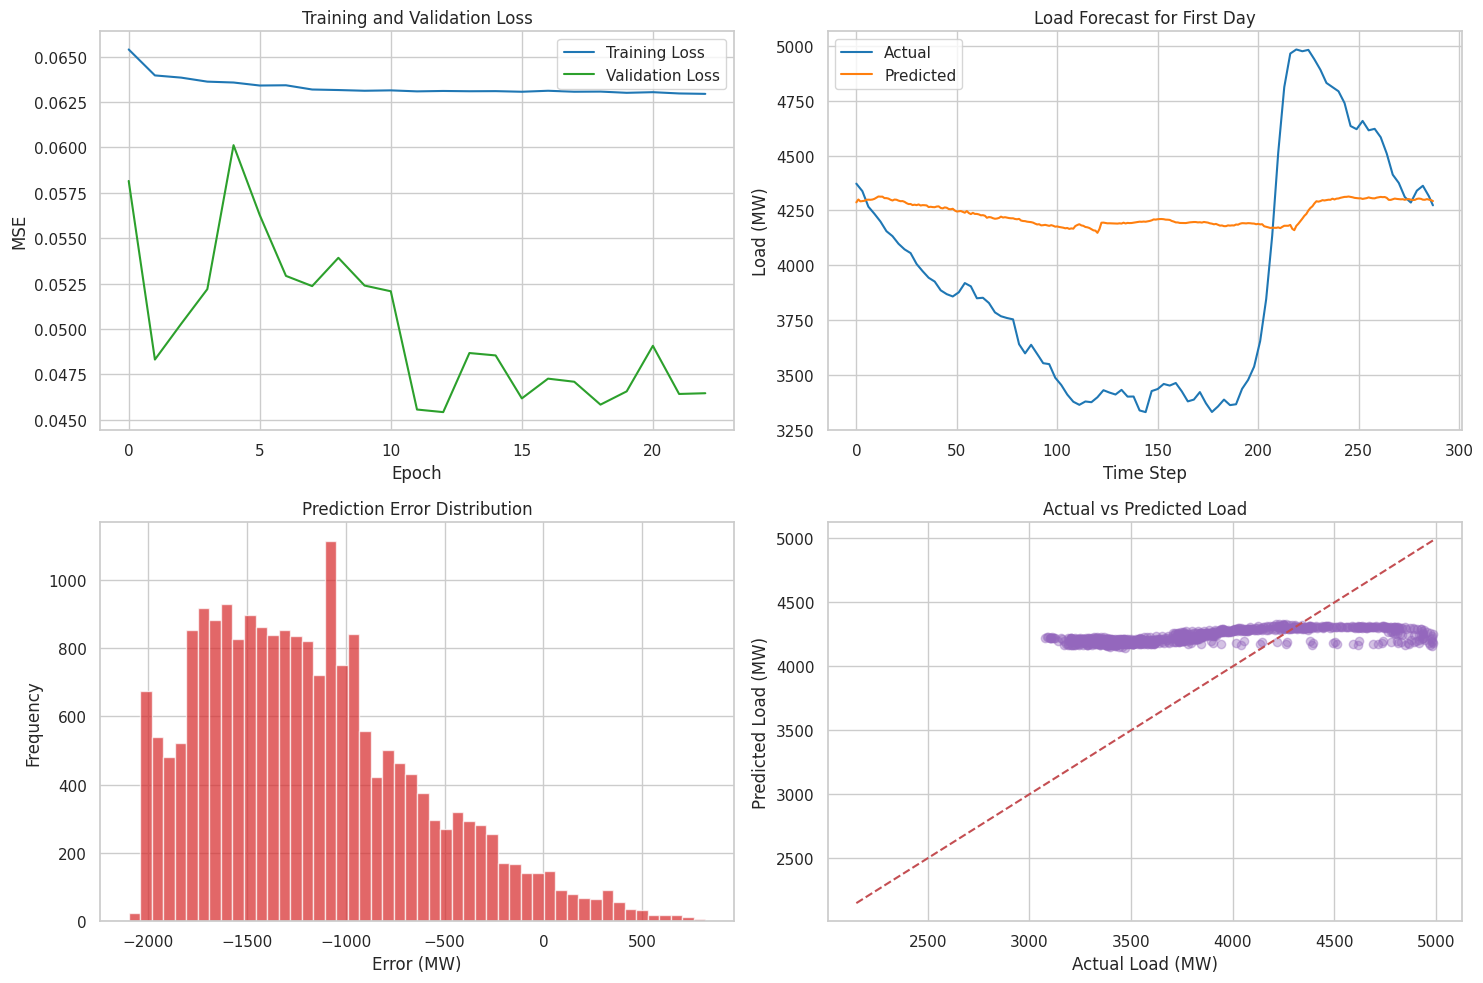

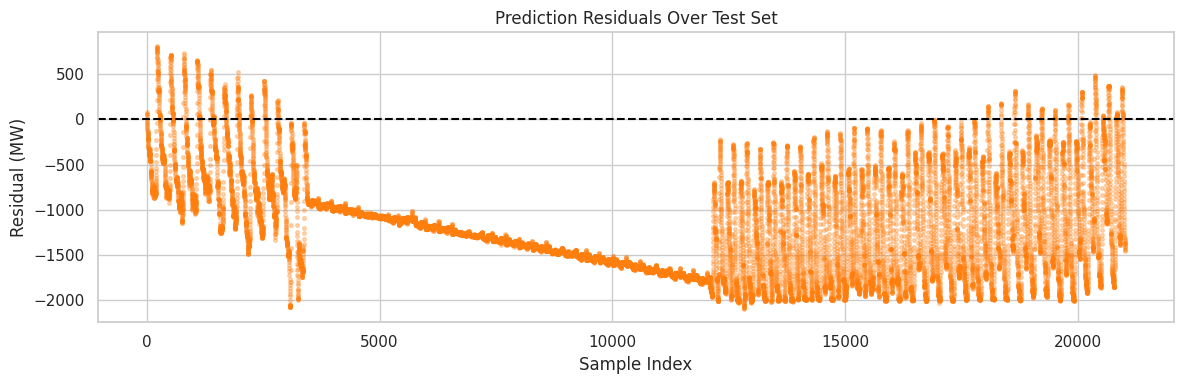

In [ ]:
#7
from sklearn.preprocessing import MinMaxScaler
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

def train_stlf_model(base_path, seq_len=12):
    demand_df = pd.read_csv(os.path.join(base_path, 'data', 'demand_5min.csv'), parse_dates=['datetime'], index_col='datetime')
    features_df = pd.read_csv(os.path.join(base_path, 'data', 'features_5min.csv'), parse_dates=['datetime'], index_col='datetime')
    target_col = 'BSEB Act'
    if target_col not in demand_df.columns:
        raise KeyError(f"Target column '{target_col}' not found.")

    feature_cols = [c for c in features_df.columns if not c.endswith('_lag1')]
    X_all = features_df[feature_cols].values
    y_all = demand_df[target_col].values

    def create_sequences(X, y, seq_len):
        X_seq, y_seq = [], []
        for i in range(len(X) - seq_len):
            X_seq.append(X[i:i+seq_len])
            y_seq.append(y[i+seq_len])
        return np.array(X_seq), np.array(y_seq)

    X_seq, y_seq = create_sequences(X_all, y_all, seq_len)
    train_size = int(0.8 * len(X_seq))
    X_train, X_test = X_seq[:train_size], X_seq[train_size:]
    y_train, y_test = y_seq[:train_size], y_seq[train_size:]

    scaler_X = MinMaxScaler().fit(X_train.reshape(-1, X_train.shape[-1]))
    scaler_y = MinMaxScaler().fit(y_train.reshape(-1,1))

    X_train_scaled = scaler_X.transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
    X_test_scaled = scaler_X.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)
    y_train_scaled = scaler_y.transform(y_train.reshape(-1,1)).flatten()
    y_test_scaled = scaler_y.transform(y_test.reshape(-1,1)).flatten()

    model = build_advanced_model((X_train.shape[1], X_train.shape[2]))

    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
    ]

    history = model.fit(
        X_train_scaled, y_train_scaled,
        validation_split=0.2,
        epochs=100,
        batch_size=64,
        callbacks=callbacks,
        verbose=1
    )

    y_pred_scaled = model.predict(X_test_scaled)
    print("Model prediction raw shape:", y_pred_scaled.shape)

    # Fix output shape: if 3D output, take only last timestep prediction per sequence
    if y_pred_scaled.ndim == 3:
        y_pred_scaled = y_pred_scaled[:, -1, :]
    if y_pred_scaled.ndim == 2 and y_pred_scaled.shape[1] == 1:
        y_pred_scaled = y_pred_scaled.flatten()

    y_test_orig = scaler_y.inverse_transform(y_test_scaled.reshape(-1,1)).flatten()
    y_pred_orig = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).flatten()

    assert y_test_orig.shape == y_pred_orig.shape, "Mismatch between true and predicted array shapes!"

    # Compute evaluation metrics
    mae = mean_absolute_error(y_test_orig, y_pred_orig)
    mse = mean_squared_error(y_test_orig, y_pred_orig)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_test_orig - y_pred_orig) / (y_test_orig + 1e-8))) * 100
    med_ae = median_absolute_error(y_test_orig, y_pred_orig)
    r2 = r2_score(y_test_orig, y_pred_orig)

    print("\nModel Evaluation Metrics:")
    print(f"MAE            : {mae:.4f} MW")
    print(f"MSE            : {mse:.4f}")
    print(f"RMSE           : {rmse:.4f} MW")
    print(f"MAPE           : {mape:.4f}%")
    print(f"Median AE      : {med_ae:.4f} MW")
    print(f"R² Score       : {r2:.4f}")
    print(f"Actual mean±std: {np.mean(y_test_orig):.2f} ± {np.std(y_test_orig):.2f} MW")

    naive_pred = y_test_orig[:-1]
    naive_rmse = np.sqrt(mean_squared_error(y_test_orig[1:], naive_pred))
    print(f"Naive RMSE (previous value): {naive_rmse:.4f} MW")

    model.save(os.path.join(base_path, 'models', 'stlf_model.h5'))
    joblib.dump(scaler_X, os.path.join(base_path, 'models', 'scaler_X.pkl'))
    joblib.dump(scaler_y, os.path.join(base_path, 'models', 'scaler_y.pkl'))

    # Diagnostic plots
    pal = sns.color_palette("tab10")
    plt.figure(figsize=(15, 10))
    sns.set_theme(style="whitegrid")

    plt.subplot(2, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss', color=pal[0])
    plt.plot(history.history['val_loss'], label='Validation Loss', color=pal[2])
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(y_test_orig[:288], label='Actual', color=pal[0])
    plt.plot(y_pred_orig[:288], label='Predicted', color=pal[1])
    plt.title('Load Forecast for First Day')
    plt.xlabel('Time Step')
    plt.ylabel('Load (MW)')
    plt.legend()

    plt.subplot(2, 2, 3)
    plt.hist(y_test_orig - y_pred_orig, bins=50, color=pal[3], alpha=0.7)
    plt.title('Prediction Error Distribution')
    plt.xlabel('Error (MW)')
    plt.ylabel('Frequency')

    plt.subplot(2, 2, 4)
    plt.scatter(y_test_orig[:1000], y_pred_orig[:1000], alpha=0.4, color=pal[4])
    plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 'r--')
    plt.title('Actual vs Predicted Load')
    plt.xlabel('Actual Load (MW)')
    plt.ylabel('Predicted Load (MW)')

    plt.tight_layout()
    plt.savefig(os.path.join(base_path, 'plots', 'stlf_results.png'), dpi=300)
    plt.show()

    plt.figure(figsize=(12, 4))
    residuals = y_test_orig - y_pred_orig
    plt.scatter(range(len(residuals)), residuals, s=7, alpha=0.3, color=pal[1])
    plt.axhline(0, linestyle='--', color='black')
    plt.title("Prediction Residuals Over Test Set")
    plt.xlabel("Sample Index")
    plt.ylabel("Residual (MW)")
    plt.tight_layout()
    plt.show()

    return model, (mae, mse, rmse, mape, med_ae, r2), (y_test_orig, y_pred_orig), demand_df, scaler_y, seq_len

model, metrics, (y_test_orig, y_pred_orig), demand_df, scaler_y, seq_len = train_stlf_model(base_path)

Columns in log_df: ['time', 'demand', 'generation', 'imbalance', 'action']
ADMS log saved to /content/drive/MyDrive/STLF_project/logs/adms_log.csv
Total load shed events: 3
Total load restore events: 0


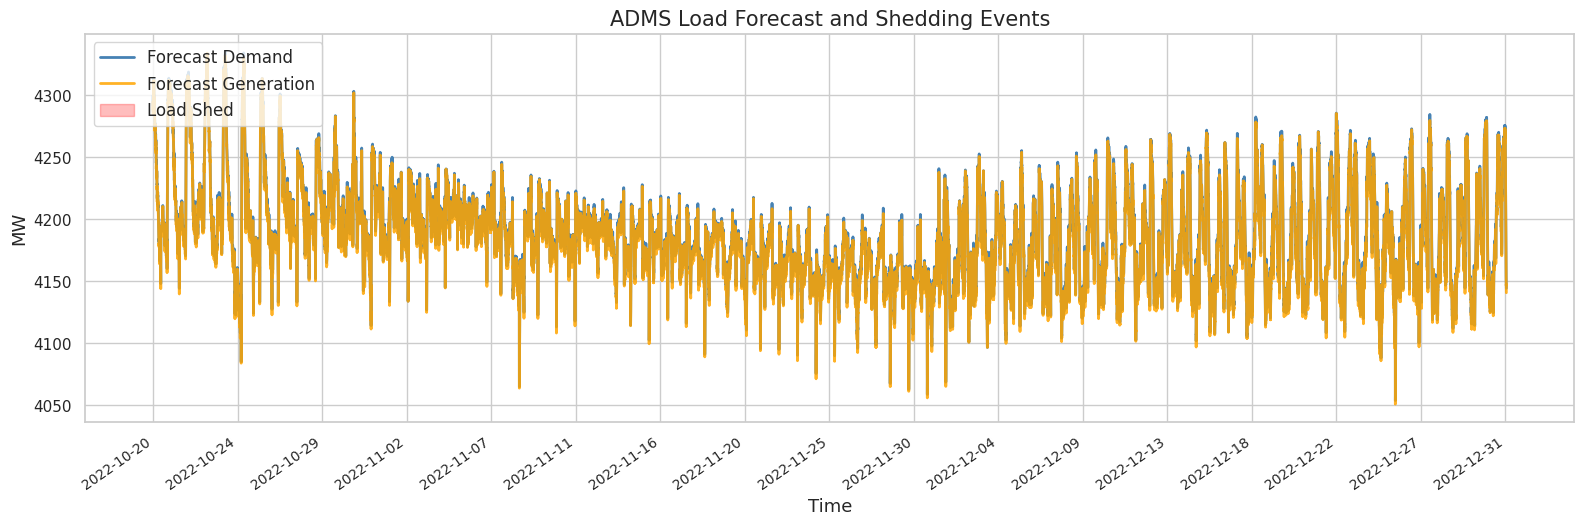

In [ ]:
#8
import pandas as pd
import numpy as np
import os
from pulp import LpProblem, LpVariable, LpMinimize, lpSum, LpBinary, PulpSolverError
import matplotlib.pyplot as plt
import seaborn as sns

#construct demand forecast DataFrame from model output (y_pred_orig) and demand_df (timestamps)
forecast_start = demand_df.index[-len(y_pred_orig)] if len(y_pred_orig) <= len(demand_df) else pd.Timestamp.now()
forecast_times = pd.date_range(start=forecast_start, periods=len(y_pred_orig), freq='5min')

demand_forecast_df = pd.DataFrame({
    "time": forecast_times.strftime('%Y-%m-%d %H:%M'),
    "demand_mw": np.round(y_pred_orig, 2)
})

#for demonstration: synthetic generation forecast (replace with your real generation forecast csv if available)
np.random.seed(42)
generation_forecast_df = demand_forecast_df.copy()
generation_forecast_df["generation_mw"] = (generation_forecast_df["demand_mw"]
                                           - np.random.uniform(0, 5, len(generation_forecast_df))).clip(lower=0)

df_adms = pd.merge(demand_forecast_df, generation_forecast_df[["time", "generation_mw"]], on="time")

loads = [
    {"name": "EV_charger", "power": 5, "priority": 3},
    {"name": "AC_unit", "power": 3, "priority": 2},
    {"name": "Industrial_pump", "power": 7, "priority": 1}
]

load_names = [l["name"] for l in loads]
load_powers = {l["name"]: l["power"] for l in loads}
load_costs = {l["name"]: l["priority"] for l in loads}
load_status = {name: True for name in load_names}
restore_cooldown = {name: 0 for name in load_names}
buffer = 2    #MW buffer threshold
cooldown = 3  #cooldown intervals before restoring a load

adms_log = []

for i, row in df_adms.iterrows():
    time = row['time']
    demand = row['demand_mw']
    generation = row['generation_mw']
    imbalance = demand - generation
    action = []

    #update cooldown timers
    for name in restore_cooldown:
        if restore_cooldown[name] > 0:
            restore_cooldown[name] -= 1

    if imbalance > buffer:
        prob = LpProblem("Shed_Loads", LpMinimize)
        x = {name: LpVariable(name, cat=LpBinary) for name in load_names if load_status[name]}
        prob += lpSum([load_costs[name] * x[name] for name in x]), "TotalShedPriorityCost"
        prob += lpSum([load_powers[name] * x[name] for name in x]) >= imbalance
        try:
            prob.solve()
            for name in x:
                if x[name].varValue == 1:
                    load_status[name] = False
                    restore_cooldown[name] = cooldown
                    action.append(f"shed {name}")
        except PulpSolverError:
            action.append("solver failed")
    elif generation - demand > buffer:
        for name in load_names:
            if not load_status[name] and restore_cooldown[name] == 0:
                load_status[name] = True
                action.append(f"restored {name}")

    adms_log.append({
        "time": time,
        "demand": demand,
        "generation": generation,
        "imbalance": imbalance,
        "action": "; ".join(action) if action else "none"
    })

log_df = pd.DataFrame(adms_log)

print("Columns in log_df:", log_df.columns.tolist())

if 'action' in log_df.columns:
    shed_count = log_df['action'].str.contains("shed").sum()
    restore_count = log_df['action'].str.contains("restored").sum()
else:
    shed_count = restore_count = 0
    print("Warning: 'action' column missing in ADMS logs.")

print(f"ADMS log saved to {os.path.join(base_path, 'logs', 'adms_log.csv')}")
print(f"Total load shed events: {shed_count}")
print(f"Total load restore events: {restore_count}")

#save ADMS log
log_path = os.path.join(base_path, "logs", "adms_log.csv")
os.makedirs(os.path.dirname(log_path), exist_ok=True)
log_df.to_csv(log_path, index=False)

#plot demand, generation, and load shed actions with clean x-axis ticks
log_df['time'] = pd.to_datetime(log_df['time'])

plt.figure(figsize=(16, 5))
sns.set_theme(style="whitegrid")
plt.plot(log_df['time'], log_df['demand'], label='Forecast Demand', color='steelblue', linewidth=2)
plt.plot(log_df['time'], log_df['generation'], label='Forecast Generation', color='orange', linewidth=2, alpha=0.85)
plt.fill_between(
    log_df['time'], log_df['demand'], log_df['generation'],
    where=log_df['action'].str.contains("shed"),
    color='red', alpha=0.26, label='Load Shed'
)

plt.title("ADMS Load Forecast and Shedding Events", fontsize=15)
plt.xlabel("Time", fontsize=13)
plt.ylabel("MW", fontsize=13)
plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()

ax = plt.gca()
n_ticks = len(log_df)
max_ticks = 16
if n_ticks > max_ticks:
    step = n_ticks // max_ticks
    plt.xticks(log_df['time'][::step], rotation=35, ha='right', fontsize=10)
else:
    plt.xticks(rotation=35, ha='right', fontsize=10)

plt.show()